In [14]:
from TdCARS2 import TdCARS
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#import scienceplots
#plt.style.use(['science'])

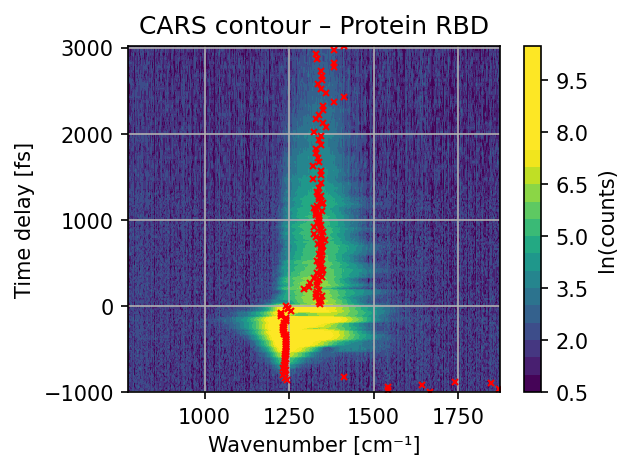

In [15]:
cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\May_28\RBD_6.dat"
CARS = TdCARS.from_file(cars_file_path)
_ = CARS.get_spectra_contour(show_plot=True)

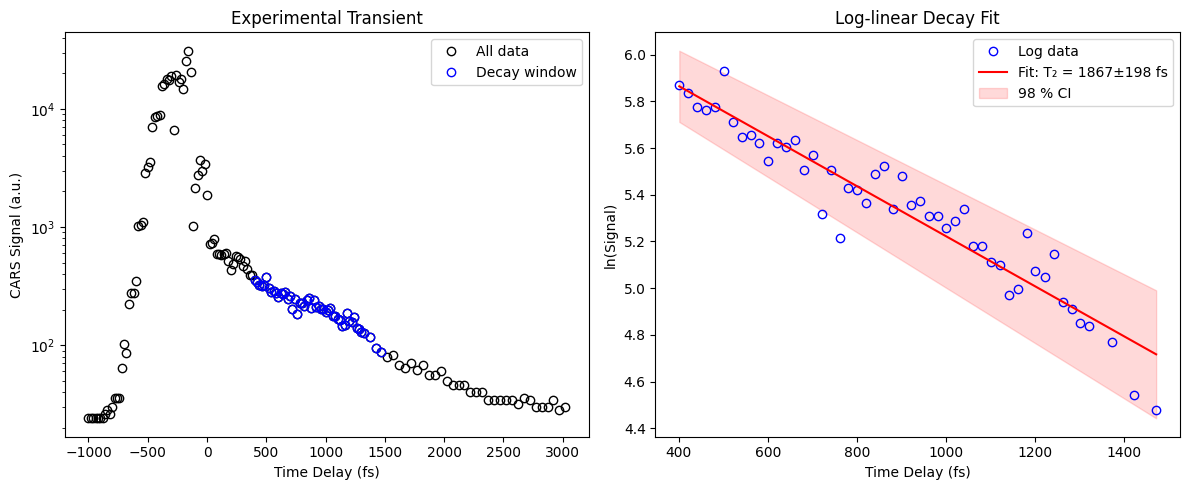

In [16]:
_ = CARS.get_T2(400,1500,show_plot=True)

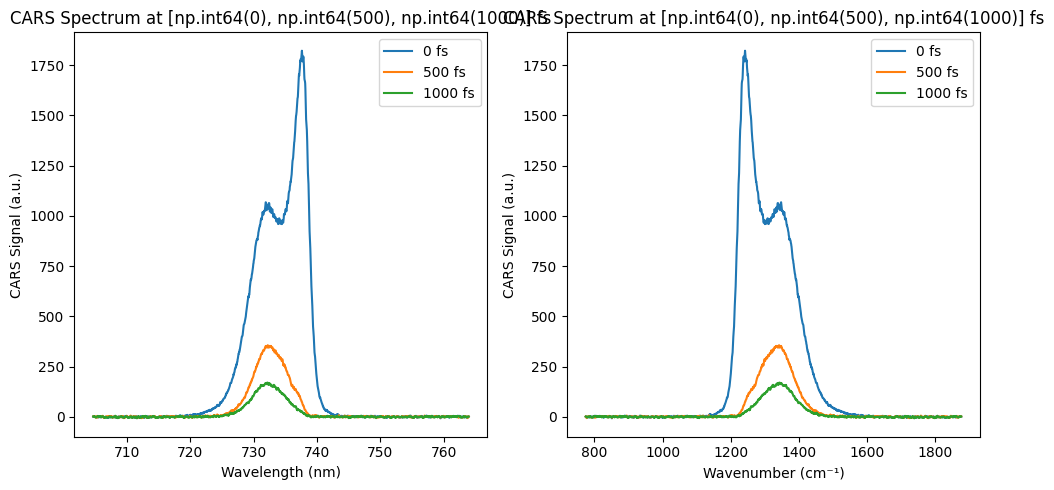

In [17]:
_ = CARS.plot_spectra_at_td([0, 500, 1000], show_plot=True, boxcar_window=5)

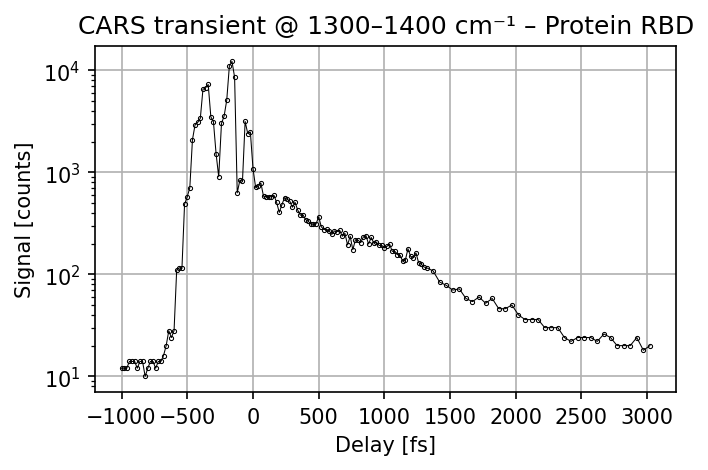

In [18]:
_ = CARS.get_transient_at_wn([1300, 1400], show_plot=True)

In [19]:
CARS.notes_df

,0,1
0,DET,Syncerity CCD
1,SMP,Protein RBD
2,P3 (TiS),117
3,P1 (OPO1),230
4,P2 (OPO2),200
5,Polarizations,All parallel
6,Ti-Sa,812
7,OPO1,1018
8,OPO2,1140
9,MONO,735


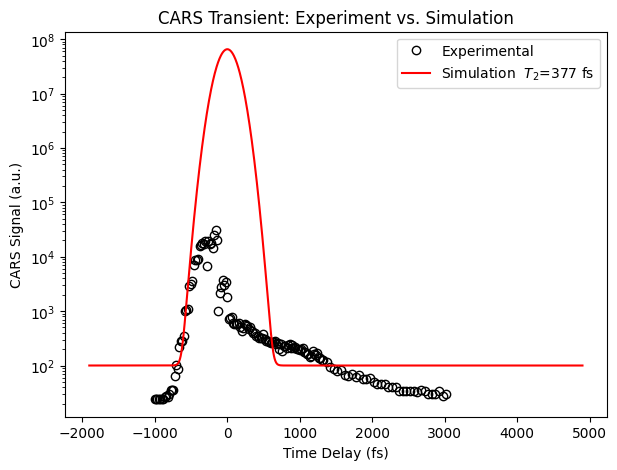

In [20]:
_ = CARS.CARS_simulation_FG(showPlot=True)

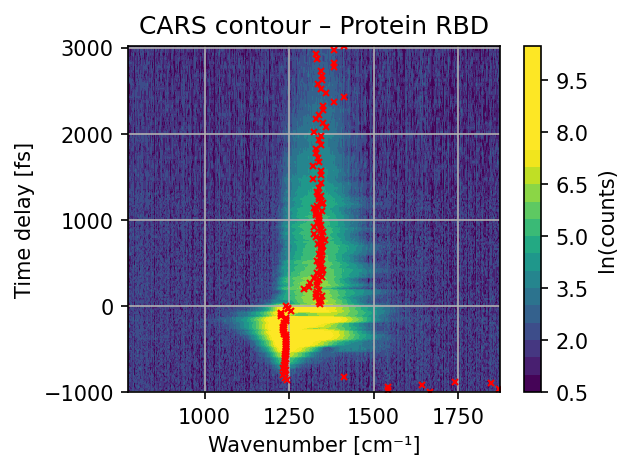

In [21]:
_ = CARS.get_spectra_contour(show_plot=True)

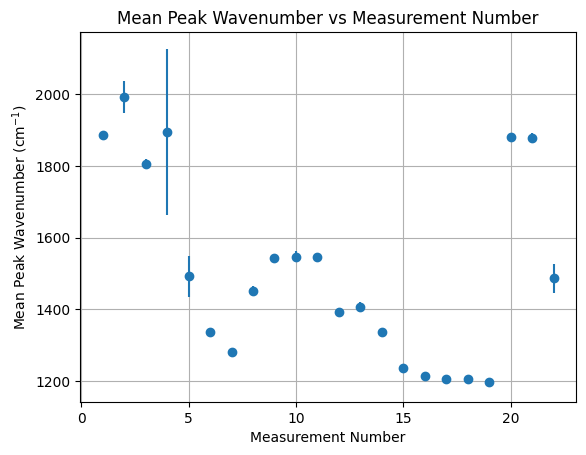

In [22]:
wn_arr = []
wn_std_arr = []
res_td_min, res_td_max = 800, 1200

for i in range(22):
    cars_file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\May_28\RBD_{}.dat".format(i+1)
    CARS = TdCARS.from_file(cars_file_path)

    # Index of maximum pixel in each row (time step)
    peak_col = np.argmax(CARS.spectra_sc_full[(CARS.td_arr >= res_td_min) & (CARS.td_arr <= res_td_max), :], axis=1)
    peak_wn = CARS.wn_as[peak_col]
    wn_arr.append(np.mean(peak_wn))
    wn_std_arr.append(np.std(peak_wn, ddof=1))

plt.errorbar(range(1, 23), wn_arr, yerr=wn_std_arr, fmt='o')
plt.xlabel('Measurement Number')
plt.ylabel('Mean Peak Wavenumber (cm$^{-1}$)')
plt.title('Mean Peak Wavenumber vs Measurement Number')
plt.grid()
plt.show()